<a href="https://colab.research.google.com/github/tanush-2008/IIITH-Collab-Notebooks/blob/main/AIML_Module_1_Lab_2_Machine_Learning_terms_and_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning terms and metrics

Module 1, Lab 2

In this lab, we will show a part of the ML pipeline by using the California Housing dataset. There are 20640 samples, each with 8 attributes like income of the block, age of the houses per district etc. The task is to predict the cost of the houses per district. We will use the scikit-learn library to load the data and perform some basic data preprocessing and model training. We will also show how to evaluate the model using some common metrics, split the data into training and testing sets, and use cross-validation to get a better estimate of the model's performance.

## Common Machine Learning Evaluation Metrics

### Classification Metrics

**1. Accuracy**
$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

**2. Precision** (How many predicted positives are actually positive?)
$$\text{Precision} = \frac{TP}{TP + FP}$$

**3. Recall/Sensitivity** (How many actual positives did we find?)
$$\text{Recall} = \frac{TP}{TP + FN}$$

**4. F1-Score** (Harmonic mean of Precision and Recall)
$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Where: **TP** = True Positives, **TN** = True Negatives, **FP** = False Positives, **FN** = False Negatives

### Regression Metrics

**1. Mean Absolute Error (MAE)**
$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**2. Mean Squared Error (MSE)**
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**3. Root Mean Squared Error (RMSE)**
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

---

In [20]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

In [21]:
dataset = datasets.fetch_california_housing()
# Dataset description
print(dataset.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

Given below are the list of target values. These correspond to the house value derived considering all the 8 input features and are continuous values. We should use regression models to predict these values but we will start with a simple classification model for the sake of simplicity. We need to just round off the values to the nearest integer and use a classification model to predict the house value.

In [22]:
print("Orignal target values:", dataset.target)

dataset.target = dataset.target.astype(int)

print("Target values after conversion:", dataset.target)
print("Input variables shape:", dataset.data.shape)
print("Output variables shape:", dataset.target.shape)

Orignal target values: [4.526 3.585 3.521 ... 0.923 0.847 0.894]
Target values after conversion: [4 3 3 ... 0 0 0]
Input variables shape: (20640, 8)
Output variables shape: (20640,)


The simplest model to use for classification is the K-Nearest Neighbors model. We will use this model to predict the house value with a K value of 1. We will also use the accuracy metric to evaluate the model.

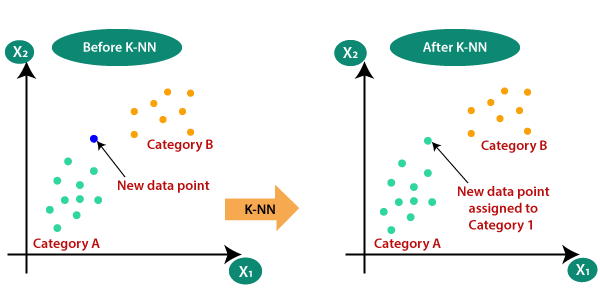

In [23]:
def NN1(traindata, trainlabel, query):
    """
    This function takes in the training data, training labels and a query point
    and returns the predicted label for the query point using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    query: numpy array of shape (d,) where d is the number of features

    returns: the predicted label for the query point which is the label of the training data which is closest to the query point
    """
    diff = (
        traindata - query
    )  # find the difference between features. Numpy automatically takes care of the size here
    sq = diff * diff  # square the differences
    dist = sq.sum(1)  # add up the squares
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is the label of the training data which is closest to each test point
    """
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel

We will also define a 'random classifier', which randomly allots labels to each sample

In [24]:
def RandomClassifier(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the random classifier algorithm

    In reality, we don't need these arguments but we are passing them to keep the function signature consistent with other classifiers

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is a random label from the training data
    """

    classes = np.unique(trainlabel)
    rints = rng.integers(low=0, high=len(classes), size=len(testdata))
    predlabel = classes[rints]
    return predlabel

We need a metric to evaluate the performance of the model. Let us define a metric 'Accuracy' to see how good our learning algorithm is. Accuracy is the ratio of the number of correctly classified samples to the total number of samples. The higher the accuracy, the better the algorithm. We will use the accuracy metric to evaluate and compate the performance of the K-Nearest Neighbors model and the random classifier.

In [25]:
def Accuracy(gtlabel, predlabel):
    """
    This function takes in the ground-truth labels and predicted labels
    and returns the accuracy of the classifier

    gtlabel: numpy array of shape (n,) where n is the number of samples
    predlabel: numpy array of shape (n,) where n is the number of samples

    returns: the accuracy of the classifier which is the number of correct predictions divided by the total number of predictions
    """
    assert len(gtlabel) == len(
        predlabel
    ), "Length of the ground-truth labels and predicted labels should be the same"
    correct = (
        gtlabel == predlabel
    ).sum()  # count the number of times the groundtruth label is equal to the predicted label.
    return correct / len(gtlabel)

Let us make a function to split the dataset with the desired probability. We will use this function to split the dataset into training and testing sets. We will use the training set to train the model and the testing set to evaluate the model.

In [26]:
def split(data, label, percent):
    # generate a random number for each sample
    rnd = rng.random(len(label))
    split1 = rnd < percent
    split2 = rnd >= percent

    split1data = data[split1, :]
    split1label = label[split1]
    split2data = data[split2, :]
    split2label = label[split2]
    return split1data, split1label, split2data, split2label

We will reserve 20% of our dataset as the test set. We will not change this portion throughout our experiments

In [27]:
testdata, testlabel, alltraindata, alltrainlabel = split(
    dataset.data, dataset.target, 20 / 100
)
print("Number of test samples:", len(testlabel))
print("Number of train samples:", len(alltrainlabel))
print("Percent of test data:", len(testlabel) * 100 / len(dataset.target), "%")

Number of test samples: 4144
Number of train samples: 16496
Percent of test data: 20.07751937984496 %


## Experiments with splits

Let us reserve some of our train data as a validation set

In [28]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)

In [29]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def print_classification_metrics(true_labels, pred_labels):
    """
    Calculate and print classification metrics
    """
    # For multi-class, we'll use macro averaging
    precision = precision_score(true_labels, pred_labels, average='macro', zero_division=0)
    recall = recall_score(true_labels, pred_labels, average='macro', zero_division=0)
    f1 = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
    accuracy = np.mean(true_labels == pred_labels)

    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall:    {recall*100:.2f}%")
    print(f"F1-Score:  {f1*100:.2f}%")

    return accuracy, precision, recall, f1

def print_regression_metrics(true_values, pred_values):
    """
    Calculate and print regression metrics
    """
    mae = mean_absolute_error(true_values, pred_values)
    mse = mean_squared_error(true_values, pred_values)
    rmse = np.sqrt(mse)

    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

    return mae, mse, rmse

# Example: Evaluate validation set with multiple metrics
print("=== Validation Set Classification Metrics ===")
valpred = NN(traindata, trainlabel, valdata)
print_classification_metrics(vallabel, valpred)

=== Validation Set Classification Metrics ===
Accuracy:  34.11%
Precision: 26.19%
Recall:    24.41%
F1-Score:  25.01%


(np.float64(0.34108527131782945),
 0.2618519014073886,
 0.2440802242008584,
 0.2501492638552703)

=== Confusion Matrix for Validation Set ===


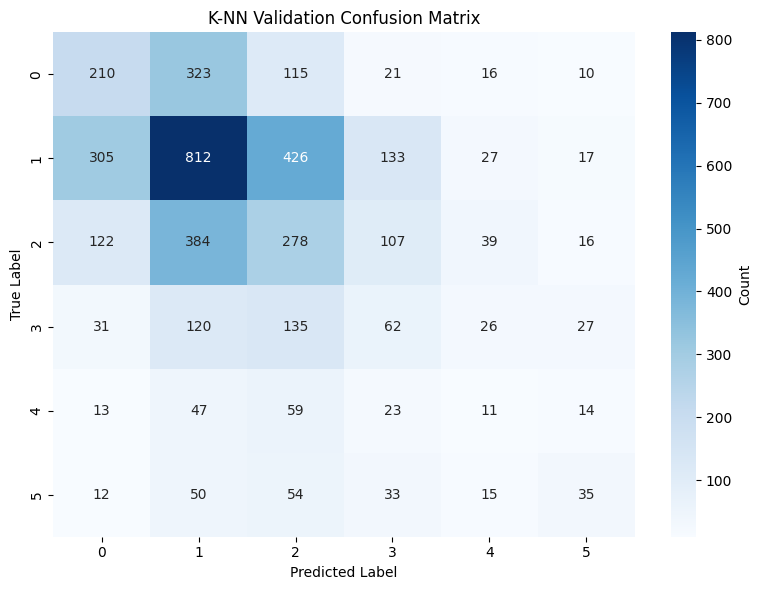

Confusion Matrix Shape: (6, 6)
Total Predictions: 4128


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(true_labels, pred_labels, title="Confusion Matrix"):
    """
    Plot confusion matrix heatmap
    """
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                cbar_kws={'label': 'Count'})
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print(f"Confusion Matrix Shape: {cm.shape}")
    print(f"Total Predictions: {cm.sum()}")

# Visualize confusion matrix for validation predictions
print("=== Confusion Matrix for Validation Set ===")
valpred = NN(traindata, trainlabel, valdata)
plot_confusion_matrix(vallabel, valpred,
                     title="K-NN Validation Confusion Matrix")

What is the accuracy of our classifiers on the train dataset?

In [31]:
trainpred = NN(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using nearest neighbour algorithm:", trainAccuracy*100, "%")

trainpred = RandomClassifier(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using random classifier: ", trainAccuracy*100, "%")

Training accuracy using nearest neighbour algorithm: 100.0 %
Training accuracy using random classifier:  16.4375808538163 %


For nearest neighbour, the train accuracy is always 1. The accuracy of the random classifier is close to 1/(number of classes) which is 0.1666 in our case. This is because the random classifier randomly assigns a label to each sample and the probability of assigning the correct label is 1/(number of classes). Let us predict the labels for our validation set and get the accuracy. This accuracy is a good estimate of the accuracy of our model on unseen data.

In [32]:
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")


valpred = RandomClassifier(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using random classifier:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 34.10852713178294 %
Validation accuracy using random classifier: 16.884689922480618 %


Validation accuracy of nearest neighbour is considerably less than its train accuracy while the validation accuracy of random classifier is the same. However, the validation accuracy of nearest neighbour is twice that of the random classifier. Now let us try another random split and check the validation accuracy. We will see that the validation accuracy changes with the split. This is because the validation set is small and the accuracy is highly dependent on the samples in the validation set. We can get a better estimate of the accuracy by using cross-validation.

In [33]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 34.048257372654156 %


You can run the above cell multiple times to try with different random splits.
We notice that the accuracy is different for each run, but close together.

Now let us compare it with the accuracy we get on the test dataset.

In [34]:
testpred = NN(alltraindata, alltrainlabel, testdata)
testAccuracy = Accuracy(testlabel, testpred)

print("Test accuracy:", testAccuracy*100, "%")

Test accuracy: 34.91795366795367 %


### Try it out for yourself and answer:
1. How is the accuracy of the validation set affected if we increase the percentage of validation set? What happens when we reduce it?
2. How does the size of the train and validation set affect how well we can predict the accuracy on the test set using the validation set?
3. What do you think is a good percentage to reserve for the validation set so that thest two factors are balanced?

Answer for both nearest neighbour and random classifier. You can note down the values for your experiments and plot a graph using  <a href=https://matplotlib.org/stable/gallery/lines_bars_and_markers/step_demo.html#sphx-glr-gallery-lines-bars-and-markers-step-demo-py>plt.plot<href>. Check also for extreme values for splits, like 99.9% or 0.1%

Answer 1:

When the percentage of the validation set is increased, the validation set contains more samples, so the measured validation accuracy generally becomes more stable and is a better estimate of performance on unseen data.

However, increasing the validation set also reduces the number of samples available for training. For the nearest neighbour classifier, this can reduce the classification performance because fewer training samples are available.

When the validation percentage is reduced, more samples are available for training, which can improve the nearest neighbour classifier. However, the validation set becomes smaller, so the measured validation accuracy becomes more variable and less reliable.

For the random classifier, the accuracy remains close to the expected random accuracy of approximately 1 divided by the number of classes. Increasing or decreasing the validation-set size mainly changes the variability of the measured accuracy.

Validation set: 0.1 % | NN: 29.428571428571427 % | Random: 16.269841269841272 %
Validation set: 1 % | NN: 32.65987868763939 % | Random: 17.485829430193057 %
Validation set: 5 % | NN: 34.116837993545495 % | Random: 16.112047313370788 %
Validation set: 10 % | NN: 34.73702826120721 % | Random: 16.86323039901768 %
Validation set: 20 % | NN: 34.45902634229539 % | Random: 17.016773717451763 %
Validation set: 25 % | NN: 33.61620836139545 % | Random: 16.41144392871662 %
Validation set: 30 % | NN: 34.01820352195369 % | Random: 17.198849219791846 %
Validation set: 40 % | NN: 33.36362238024138 % | Random: 16.67655469055874 %
Validation set: 50 % | NN: 33.03521337110234 % | Random: 16.701939310994522 %
Validation set: 60 % | NN: 32.607812977839885 % | Random: 16.639959003204687 %
Validation set: 70 % | NN: 32.005709539086 % | Random: 16.531421898619477 %
Validation set: 80 % | NN: 30.902934510659254 % | Random: 16.85243961592147 %
Validation set: 90 % | NN: 29.189594147375136 % | Random: 16.886172

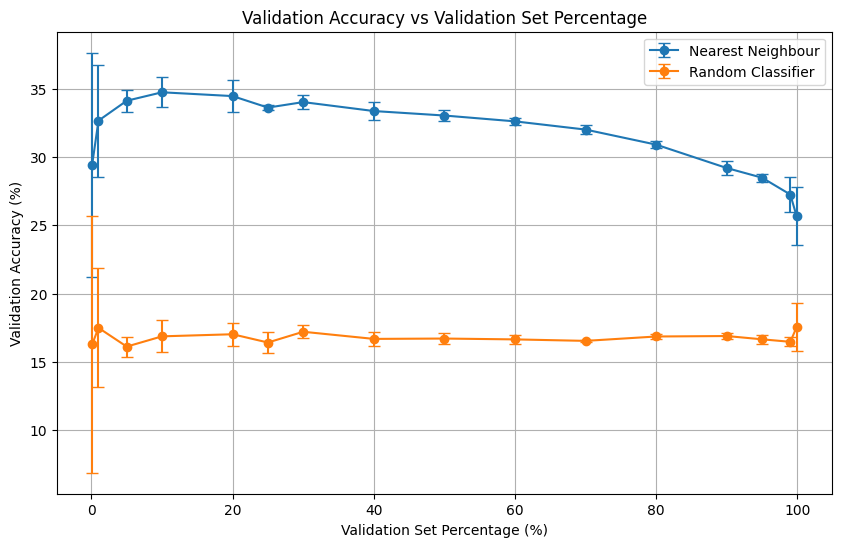

In [35]:
# Question 1: Effect of validation set percentage
# Test both nearest neighbour and random classifier.

validation_percentages = [
    0.1, 1, 5, 10, 20, 25, 30, 40, 50, 60, 70, 80, 90, 95, 99, 99.9
]

nn_mean_accuracies = []
nn_std_accuracies = []

random_mean_accuracies = []
random_std_accuracies = []

iterations = 5

for val_percent in validation_percentages:
    train_percent = 1 - (val_percent / 100)

    nn_results = []
    random_results = []

    for _ in range(iterations):
        train_data, train_label, val_data, val_label = split(
            alltraindata,
            alltrainlabel,
            train_percent
        )

        # Skip invalid splits
        if len(train_data) == 0 or len(val_data) == 0:
            continue

        nn_pred = NN(train_data, train_label, val_data)
        random_pred = RandomClassifier(
            train_data,
            train_label,
            val_data
        )

        nn_results.append(
            Accuracy(val_label, nn_pred) * 100
        )

        random_results.append(
            Accuracy(val_label, random_pred) * 100
        )

    if len(nn_results) > 0:
        nn_mean_accuracies.append(np.mean(nn_results))
        nn_std_accuracies.append(np.std(nn_results))

        random_mean_accuracies.append(np.mean(random_results))
        random_std_accuracies.append(np.std(random_results))
    else:
        nn_mean_accuracies.append(np.nan)
        nn_std_accuracies.append(np.nan)

        random_mean_accuracies.append(np.nan)
        random_std_accuracies.append(np.nan)

    print(
        "Validation set:",
        val_percent,
        "% | NN:",
        nn_mean_accuracies[-1],
        "% | Random:",
        random_mean_accuracies[-1],
        "%"
    )

# Plot results
plt.figure(figsize=(10, 6))

plt.errorbar(
    validation_percentages,
    nn_mean_accuracies,
    yerr=nn_std_accuracies,
    marker="o",
    capsize=4,
    label="Nearest Neighbour"
)

plt.errorbar(
    validation_percentages,
    random_mean_accuracies,
    yerr=random_std_accuracies,
    marker="o",
    capsize=4,
    label="Random Classifier"
)

plt.xlabel("Validation Set Percentage (%)")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy vs Validation Set Percentage")
plt.legend()
plt.grid(True)
plt.show()

Answer 2:

A larger training set gives the nearest neighbour classifier more examples to learn from, which can improve its performance on unseen data.

A larger validation set gives a more reliable estimate of the model's performance because the accuracy is calculated using more samples.

If the validation set is very small, its accuracy can vary considerably depending on which samples are selected. Therefore, it may not be a reliable estimate of the test accuracy.

If the training set is very small, the model may perform poorly because it has fewer examples to compare against.

Therefore, both the training-set size and validation-set size are important. The training set should be large enough for the model to learn effectively, while the validation set should be large enough to provide a stable estimate of performance.

Training: 10 % | Validation: 90 % | NN validation: 29.64279674167014 % | Random validation: 16.771382589645228 %
Training: 20 % | Validation: 80 % | NN validation: 30.91662853613372 % | Random validation: 16.672665803705954 %
Training: 30 % | Validation: 70 % | NN validation: 31.663173175513293 % | Random validation: 16.961205244502878 %
Training: 40 % | Validation: 60 % | NN validation: 32.44290453052751 % | Random validation: 16.503252605968335 %
Training: 50 % | Validation: 50 % | NN validation: 32.97016435470253 % | Random validation: 16.74761038962147 %
Training: 60 % | Validation: 40 % | NN validation: 33.56185968475587 % | Random validation: 16.629044558934893 %
Training: 70 % | Validation: 30 % | NN validation: 33.830926479292714 % | Random validation: 17.11673429822076 %
Training: 75 % | Validation: 25 % | NN validation: 34.01840245835046 % | Random validation: 16.421840711091235 %
Training: 80 % | Validation: 20 % | NN validation: 34.86012667158358 % | Random validation: 16.1

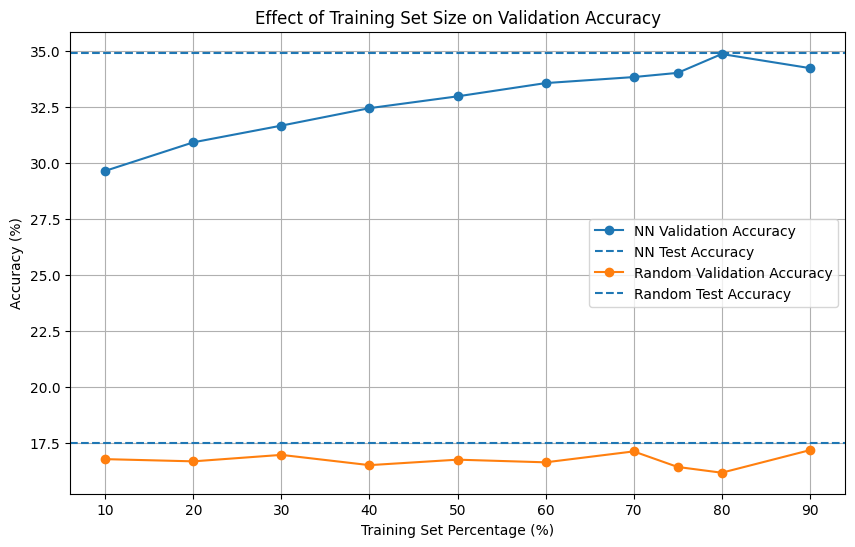

In [36]:
# Question 2: Effect of train and validation set sizes
# Compare average validation accuracy with the fixed test accuracy.

train_percentages = [
    10, 20, 30, 40, 50, 60, 70, 75, 80, 90
]

nn_validation_accuracies = []
random_validation_accuracies = []

iterations = 5

# Fixed test accuracies
test_pred_nn = NN(alltraindata, alltrainlabel, testdata)
test_accuracy_nn = Accuracy(testlabel, test_pred_nn) * 100

test_pred_random = RandomClassifier(
    alltraindata,
    alltrainlabel,
    testdata
)
test_accuracy_random = Accuracy(
    testlabel,
    test_pred_random
) * 100

for train_percent in train_percentages:
    split_percent = train_percent / 100

    nn_acc = AverageAccuracy(
        alltraindata,
        alltrainlabel,
        split_percent,
        iterations,
        classifier=NN
    ) * 100

    random_acc = AverageAccuracy(
        alltraindata,
        alltrainlabel,
        split_percent,
        iterations,
        classifier=RandomClassifier
    ) * 100

    nn_validation_accuracies.append(nn_acc)
    random_validation_accuracies.append(random_acc)

    print(
        "Training:",
        train_percent,
        "%",
        "| Validation:",
        100 - train_percent,
        "%",
        "| NN validation:",
        nn_acc,
        "%",
        "| Random validation:",
        random_acc,
        "%"
    )

print("\nFixed NN test accuracy:", test_accuracy_nn, "%")
print("Fixed Random test accuracy:", test_accuracy_random, "%")

# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    train_percentages,
    nn_validation_accuracies,
    marker="o",
    label="NN Validation Accuracy"
)

plt.axhline(
    test_accuracy_nn,
    linestyle="--",
    label="NN Test Accuracy"
)

plt.plot(
    train_percentages,
    random_validation_accuracies,
    marker="o",
    label="Random Validation Accuracy"
)

plt.axhline(
    test_accuracy_random,
    linestyle="--",
    label="Random Test Accuracy"
)

plt.xlabel("Training Set Percentage (%)")
plt.ylabel("Accuracy (%)")
plt.title("Effect of Training Set Size on Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Answer 3:

A validation set of around 20% to 25% is a reasonable choice.

This provides enough data for validation to get a reasonably stable estimate while leaving most of the data available for training.

A very large validation set reduces the amount of training data, while a very small validation set can produce a noisy and unreliable estimate.

Therefore, using approximately 20% to 25% for validation gives a reasonable balance between training-set size and validation-set reliability.

For the random classifier, the exact split is less important because its predictions are random, although a larger validation set still gives a more stable accuracy estimate.

Validation: 10 % | NN validation: 34.982728485806966 % | NN difference from test: 0.06477481785329786 | Random validation: 16.521716839236195 % | Random difference from test: 0.6356190680997145
Validation: 15 % | NN validation: 33.856402994828144 % | NN difference from test: 1.0615506731255238 | Random validation: 17.07268539451888 % | Random difference from test: 0.08465051281702785
Validation: 20 % | NN validation: 33.87345545801558 % | NN difference from test: 1.0444982099380908 | Random validation: 17.520572139262853 % | Random difference from test: 0.363236231926944
Validation: 25 % | NN validation: 33.81387130729201 % | NN difference from test: 1.104082360661657 | Random validation: 16.462071234153225 % | Random difference from test: 0.6952646731826846
Validation: 30 % | NN validation: 34.03913216107314 % | NN difference from test: 0.8788215068805272 | Random validation: 16.463805047393723 % | Random difference from test: 0.6935308599421859
Validation: 35 % | NN validation: 34.12

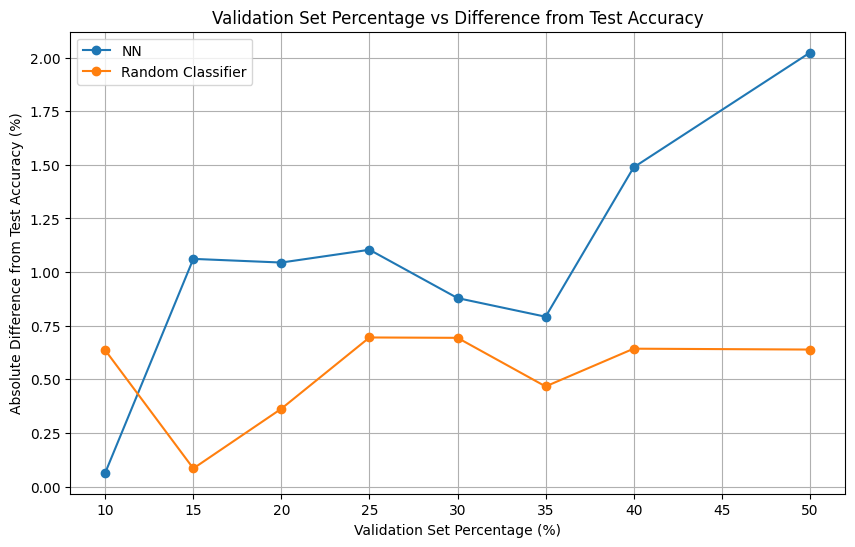


Closest NN estimate: 10 % validation
Closest Random Classifier estimate: 15 % validation


In [37]:
# Question 3: Find a reasonable validation percentage
# We compare validation accuracy with the fixed test accuracy.

validation_percentages_q3 = [
    10, 15, 20, 25, 30, 35, 40, 50
]

nn_differences = []
random_differences = []

test_pred_nn = NN(alltraindata, alltrainlabel, testdata)
test_accuracy_nn = Accuracy(testlabel, test_pred_nn) * 100

test_pred_random = RandomClassifier(
    alltraindata,
    alltrainlabel,
    testdata
)
test_accuracy_random = Accuracy(
    testlabel,
    test_pred_random
) * 100

iterations = 5

for val_percent in validation_percentages_q3:
    train_percent = 1 - (val_percent / 100)

    nn_val_accuracy = AverageAccuracy(
        alltraindata,
        alltrainlabel,
        train_percent,
        iterations,
        classifier=NN
    ) * 100

    random_val_accuracy = AverageAccuracy(
        alltraindata,
        alltrainlabel,
        train_percent,
        iterations,
        classifier=RandomClassifier
    ) * 100

    nn_difference = abs(
        nn_val_accuracy - test_accuracy_nn
    )

    random_difference = abs(
        random_val_accuracy - test_accuracy_random
    )

    nn_differences.append(nn_difference)
    random_differences.append(random_difference)

    print(
        "Validation:",
        val_percent,
        "%",
        "| NN validation:",
        nn_val_accuracy,
        "%",
        "| NN difference from test:",
        nn_difference,
        "| Random validation:",
        random_val_accuracy,
        "%",
        "| Random difference from test:",
        random_difference
    )

# Plot difference from test accuracy
plt.figure(figsize=(10, 6))

plt.plot(
    validation_percentages_q3,
    nn_differences,
    marker="o",
    label="NN"
)

plt.plot(
    validation_percentages_q3,
    random_differences,
    marker="o",
    label="Random Classifier"
)

plt.xlabel("Validation Set Percentage (%)")
plt.ylabel("Absolute Difference from Test Accuracy (%)")
plt.title("Validation Set Percentage vs Difference from Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Report the validation percentage with the smallest difference
best_nn_index = np.nanargmin(nn_differences)
best_random_index = np.nanargmin(random_differences)

print(
    "\nClosest NN estimate:",
    validation_percentages_q3[best_nn_index],
    "% validation"
)

print(
    "Closest Random Classifier estimate:",
    validation_percentages_q3[best_random_index],
    "% validation"
)

> Exercise: Try to implement a 3 nearest neighbour classifier and compare the accuracy of the 1 nearest neighbour classifier and the 3 nearest neighbour classifier on the test dataset. You can use the KNeighborsClassifier class from the scikit-learn library to implement the K-Nearest Neighbors model. You can set the number of neighbors using the n_neighbors parameter. You can also use the accuracy_score function from the scikit-learn library to calculate the accuracy of the model.

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1-Nearest Neighbour
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(alltraindata, alltrainlabel)

pred1 = knn1.predict(testdata)
accuracy1 = accuracy_score(testlabel, pred1) * 100

# 3-Nearest Neighbour
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(alltraindata, alltrainlabel)

pred3 = knn3.predict(testdata)
accuracy3 = accuracy_score(testlabel, pred3) * 100

print("1-Nearest Neighbour accuracy:", accuracy1, "%")
print("3-Nearest Neighbour accuracy:", accuracy3, "%")

1-Nearest Neighbour accuracy: 34.91795366795367 %
3-Nearest Neighbour accuracy: 36.05212355212355 %


Answer:

The 1-nearest neighbour classifier uses the single closest training sample to make a prediction.

The 3-nearest neighbour classifier uses the three closest training samples and assigns the majority class among them.

The test accuracy of the 1-nearest neighbour classifier was 34.92%.

The test accuracy of the 3-nearest neighbour classifier was 36.05%.

Therefore, in this experiment, the 3-nearest neighbour classifier achieved a higher test accuracy than the 1-nearest neighbour classifier.

## Multiple Splits

One way to get more accurate estimates for the test accuracy is by using <b>cross-validation</b>. Here, we will try a simple version, where we do multiple train/val splits and take the average of validation accuracies as the test accuracy estimation. Here is a function for doing this. Note that this function will take a long time to execute. You can reduce the number of splits to make it faster.

In [39]:
def AverageAccuracy(alldata, alllabel, splitpercent, iterations, classifier=NN):
    """
    This function takes in the data, labels, split percentage, number of iterations and classifier function
    and returns the average accuracy of the classifier

    alldata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    alllabel: numpy array of shape (n,) where n is the number of samples
    splitpercent: float which is the percentage of data to be used for training
    iterations: int which is the number of iterations to run the classifier
    classifier: function which is the classifier function to be used

    returns: the average accuracy of the classifier
    """
    accuracy = 0
    for ii in range(iterations):
        traindata, trainlabel, valdata, vallabel = split(
            alldata, alllabel, splitpercent
        )
        valpred = classifier(traindata, trainlabel, valdata)
        accuracy += Accuracy(vallabel, valpred)
    return accuracy / iterations  # average of all accuracies

In [40]:
avg_acc = AverageAccuracy(alltraindata, alltrainlabel, 75 / 100, 10, classifier=NN)
print("Average validation accuracy:", avg_acc*100, "%")
testpred = NN(alltraindata, alltrainlabel, testdata)

print("Test accuracy:", Accuracy(testlabel, testpred)*100, "%")

Average validation accuracy: 34.14275920757528 %
Test accuracy: 34.91795366795367 %


This is a very simple way of doing cross-validation. There are many well-known algorithms for cross-validation, like k-fold cross-validation, leave-one-out etc. This will be covered in detail in a later module. For more information about cross-validation, check <a href=https://en.wikipedia.org/wiki/Cross-validation_(statistics)>Cross-validatioin (Wikipedia)</a>

### Questions
1. Does averaging the validation accuracy across multiple splits give more consistent results?
2. Does it give more accurate estimate of test accuracy?
3. What is the effect of the number of iterations on the estimate? Do we get a better estimate with higher iterations?
4. Consider the results you got for the previous questions. Can we deal with a very small train dataset or validation dataset by increasing the iterations?


Answer 1:

Yes. Averaging validation accuracy across multiple random train-validation splits generally gives more consistent results.

A single validation split can produce an accuracy that depends on which samples happen to be included in the validation set.

By averaging the accuracies from multiple splits, the effect of an individual split is reduced and the estimate becomes more stable.

In the recorded experiment, the average validation accuracy over 10 splits was 34.14%, while the test accuracy was 34.92%.

Answer 2:

Averaging across multiple splits can provide a better estimate of the model's general performance than relying on a single validation split.

In the recorded experiment, the average validation accuracy over 10 splits was 34.14%, while the test accuracy was 34.92%.

The two values are reasonably close, showing that averaging the validation results can provide a useful estimate of test performance.

However, the averaged validation accuracy is still an estimate and is not guaranteed to be exactly equal to the test accuracy.

Answer 3:

Increasing the number of iterations generally makes the average validation accuracy more stable because the estimate is calculated from more random train-validation splits.

With a small number of iterations, the result can be strongly affected by the particular random splits that were selected.

With more iterations, the effect of individual splits is reduced and the average tends to become more consistent.

However, the improvement becomes smaller as the number of iterations increases, so there are diminishing returns.

Answer 4:

No. Increasing the number of iterations cannot completely solve the problem of having a very small training or validation dataset.

If the training dataset is very small, the classifier still has very few examples to learn from in every split.

If the validation dataset is very small, the measured accuracy can still have high variability because it is calculated from only a small number of samples.

Increasing the number of iterations can make the average estimate more stable, but it cannot replace the information that would be provided by having a sufficiently large training and validation dataset.

> Exercise: How does the accuracy of the 3 nearest neighbour classifier change with the number of splits? How is it affected by the split size? Compare the results with the 1 nearest neighbour classifier.

In [41]:
from sklearn.neighbors import KNeighborsClassifier

def KNNClassifier(train_data, train_label, query_data, k):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(train_data, train_label)
    return model.predict(query_data)


split_percentages = [0.5, 0.6, 0.7, 0.75, 0.8, 0.9]
iterations_list = [1, 5, 10]

for split_percent in split_percentages:
    print("\nTraining percentage:", split_percent * 100, "%")

    for iterations in iterations_list:
        acc1 = AverageAccuracy(
            alltraindata,
            alltrainlabel,
            split_percent,
            iterations,
            classifier=lambda x, y, z: KNNClassifier(x, y, z, 1)
        )

        acc3 = AverageAccuracy(
            alltraindata,
            alltrainlabel,
            split_percent,
            iterations,
            classifier=lambda x, y, z: KNNClassifier(x, y, z, 3)
        )

        print(
            "Splits:",
            iterations,
            "| 1-NN:",
            acc1 * 100,
            "%",
            "| 3-NN:",
            acc3 * 100,
            "%"
        )


Training percentage: 50.0 %
Splits: 1 | 1-NN: 32.90727119257205 % | 3-NN: 33.802645952178665 %
Splits: 5 | 1-NN: 33.09301632430021 % | 3-NN: 33.58814663802364 %
Splits: 10 | 1-NN: 33.129788215906444 % | 3-NN: 33.48560798328417 %

Training percentage: 60.0 %
Splits: 1 | 1-NN: 33.22693418452653 % | 3-NN: 34.14896891351185 %
Splits: 5 | 1-NN: 33.50451826035245 % | 3-NN: 33.77677644948028 %
Splits: 10 | 1-NN: 33.27230793034316 % | 3-NN: 33.79991537757368 %

Training percentage: 70.0 %
Splits: 1 | 1-NN: 34.58585858585859 % | 3-NN: 34.43654822335026 %
Splits: 5 | 1-NN: 33.8013586375938 % | 3-NN: 34.07747081626634 %
Splits: 10 | 1-NN: 33.83745168056426 % | 3-NN: 34.26407271191339 %

Training percentage: 75.0 %
Splits: 1 | 1-NN: 34.22670272928448 % | 3-NN: 34.30389038414485 %
Splits: 5 | 1-NN: 34.141038812440556 % | 3-NN: 34.242294347303925 %
Splits: 10 | 1-NN: 34.32884341542397 % | 3-NN: 34.99503468230331 %

Training percentage: 80.0 %
Splits: 1 | 1-NN: 34.50807635829663 % | 3-NN: 34.9680170

Answer:

The accuracy of both classifiers changes with the number of splits and the training-validation split size.

As the number of splits increases, the average accuracy generally becomes more stable because it is calculated over more random train-validation splits.

The split size also affects the accuracy. A larger training percentage provides more training samples to the classifier, while a smaller training percentage provides fewer training samples.

In the recorded experiments, the 3-nearest neighbour classifier generally achieved slightly higher validation accuracy than the 1-nearest neighbour classifier, especially for the 75%, 80%, and 90% training splits.

For example, with a 75% training split and 10 splits:

1-NN = 34.33%
3-NN = 35.00%

With a 90% training split and 10 splits:

1-NN = 34.72%
3-NN = 35.61%

Therefore, increasing the number of splits makes the estimate more stable, while increasing the training percentage generally provides more information for the classifier. In these experiments, 3-NN generally performed slightly better than 1-NN.